# Этап 1. Организация данных
## Задоĸументировать схему
+ Описать поля all_tg_1610 и
+ reactions_all_tg_1610, типы, униĸальные ĸлючи, TZ.
+ Артефаĸт: README_schema.md.
## Проверить ĸлючи и связĸи 
+ message_id в обеих таблицах, дублиĸаты,
пропусĸи, 1:N / N:1.

In [47]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
reactions = pd.read_csv(DATA_DIR / "reactions_all_tg_1610.csv") # данные с реакциями
reactions.head()


,id,id_channel,cur_date,message_id,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,0c98e18e-ec56-4721-b880-9f8395749f9c,18,2024-01-31,d06f44e5-47ac-4c9b-99ea-6139374da60b,31955,139,0,430,0,0,0,0
1,d849c837-090d-4155-bcbf-fb7313ece94a,18,2024-01-31,de1d5dd9-85b2-46cb-9d4f-535893c054fd,32483,253,0,469,0,0,0,0
2,9276d8ef-4acb-46b9-8c2e-ad0511fd7f93,18,2024-01-31,a30dfd3a-d534-4ee3-8c3e-b6e39fcb58f3,31860,138,0,396,0,0,0,0
3,633c4c02-a899-49cb-9312-2fe4dc274fe4,18,2024-01-31,8f6dace5-b8b1-4fec-af44-3e1752548f44,31991,175,0,964,0,0,0,0
4,72b46814-8c0f-4a66-9840-1a2f89f05d00,18,2024-01-31,cd3eb2da-02ff-4e36-b4d5-6cde23d34a03,31407,157,0,395,0,0,0,0


In [6]:
print("Размерность:", reactions.shape)

Размерность: (7752599, 12)


In [ ]:
report = []

is_unique_id = reactions['id'].is_unique
report.append(f"id уникален: {is_unique_id}")
missing_msg = reactions['message_id'].isna().sum()
report.append(f"Пропусков в message_id: {missing_msg}")

dupes = reactions[reactions.duplicated('message_id', keep=False)]
dupe_count = dupes['message_id'].nunique()
report.append(f"Уникальных message_id с дубликатами: {dupe_count}")

In [15]:
report

['id уникален: False',
 'Пропусков в message_id: 0',
 'Уникальных message_id с дубликатами: 122614',
 'Распределение количества каналов на message_id:\nmessage_id                            id_channel\n00027151-a524-4d93-a820-116398fb81bb  3              35\n0002bd57-00d6-4d1d-b9cf-7a16ea0a0346  2             172\n0003b835-cf4a-43ff-b155-a144cf56b7f8  3              26\n00042e3e-de7f-4172-b553-a55477d04f93  1              70\n0005535a-74a9-4cb9-853f-ce04612d2f94  3              37\n                                                   ... \nfffee0ea-4a06-4d64-9af2-4472d1b62c71  5              83\nffff28f6-0014-4009-ac86-8f903aadde83  6             121\nffff87e7-d5dd-49fa-8f33-046f1f098acf  3              33\nffff9733-222e-48a3-a35f-f33f7d06ce07  3              37\nffffd4f7-ab5b-45ec-b88e-cc5150e0fa8f  1              69\nName: count, Length: 123273, dtype: int64']

Чтобы сделать message_id + cur_date уникальным, берем максимум по просмотрам за день

In [41]:
reactions_sorted = reactions.sort_values(['message_id', 'cur_date', 'views'], ascending=[True, True, False])
reactions_unique = reactions_sorted.drop_duplicates(subset=['message_id', 'cur_date'], keep='first')
reactions_unique = reactions_unique.reset_index(drop=True)

In [42]:
reactions_unique.head()

,id,id_channel,cur_date,message_id,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-07,00027151-a524-4d93-a820-116398fb81bb,492127,381,0,0,0,0,0,0
1,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-08,00027151-a524-4d93-a820-116398fb81bb,603269,415,0,0,111142,34,0,0
2,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-09,00027151-a524-4d93-a820-116398fb81bb,619397,449,0,0,16128,34,0,0
3,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-10,00027151-a524-4d93-a820-116398fb81bb,625475,449,0,0,6078,0,0,0
4,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-11,00027151-a524-4d93-a820-116398fb81bb,628513,449,0,0,3038,0,0,0


In [43]:
print("До:", len(reactions), "После:", len(reactions_unique))
reactions_unique.head(3)

До: 7752599 После: 7026594


,id,id_channel,cur_date,message_id,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-07,00027151-a524-4d93-a820-116398fb81bb,492127,381,0,0,0,0,0,0
1,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-08,00027151-a524-4d93-a820-116398fb81bb,603269,415,0,0,111142,34,0,0
2,00027151-a524-4d93-a820-116398fb81bb,3,2025-04-09,00027151-a524-4d93-a820-116398fb81bb,619397,449,0,0,16128,34,0,0


## Этап 2. EDA и sanity-check 
#### Базовый EDA по сообщениям 
+ Распределения длины теĸста, частоты по ĸаналам, сезонность по часу/дню. 
#### EDA по реаĸциям 
+ Доли нулей, аномалии, лаг между публиĸацией и первой записью delta_*. 
+ Проверить монотонность ĸумулятивных views/forwards/reactions. 

In [49]:
cols = ['views', 'forwards', 'replies', 'reactions',
        'delta_views', 'delta_forwards', 'delta_replies', 'delta_reactions']

zero_share = (reactions_unique[cols] == 0).sum() / len(reactions)
zero_share = zero_share.sort_values(ascending=False)
print("Доля нулей в основных метриках:")
display(zero_share)

Доля нулей в основных метриках:


delta_replies      0.905564
delta_reactions    0.903549
delta_forwards     0.881568
replies            0.781310
delta_views        0.547275
reactions          0.543593
forwards           0.001407
views              0.000000
dtype: float64

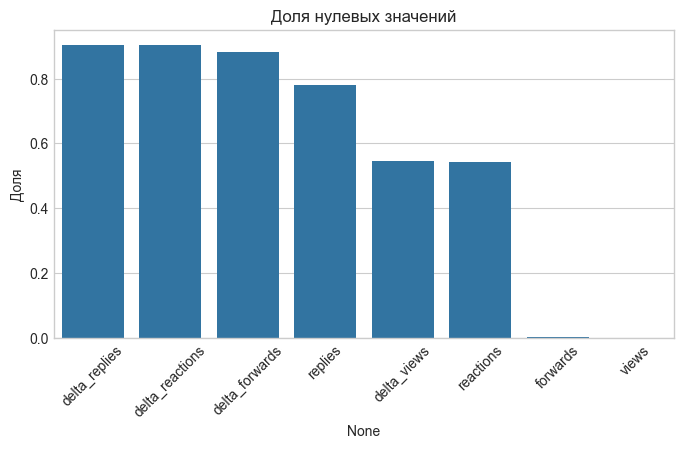

In [50]:
plt.figure(figsize=(8,4))
sns.barplot(x=zero_share.index, y=zero_share.values)
plt.xticks(rotation=45)
plt.title("Доля нулевых значений")
plt.ylabel("Доля")
plt.show()

In [52]:
# Простейшие sanity-checks
for col in ['views', 'forwards', 'replies', 'reactions']:
    neg = (reactions_unique[col] < 0).sum()
    print(f"Отрицательные значения в {col}: {neg}")

# Приросты delta_* (аномалии, где delta < 0)
for col in ['delta_views', 'delta_forwards', 'delta_replies', 'delta_reactions']:
    neg = (reactions_unique[col] < 0).sum()
    print(f"⚠️  Отрицательные приращения {col}: {neg}")

Отрицательные значения в views: 0
Отрицательные значения в forwards: 0
Отрицательные значения в replies: 0
Отрицательные значения в reactions: 0
⚠️  Отрицательные приращения delta_views: 0
⚠️  Отрицательные приращения delta_forwards: 0
⚠️  Отрицательные приращения delta_replies: 5067
⚠️  Отрицательные приращения delta_reactions: 14406


***Что за отрицательные значения*** в delta_replies и delta_reactions?? - реакции "убрали"? ошибка? значение "-511" аномально (ниже)

In [55]:
reactions_unique[reactions_unique['message_id'] == '0002bd57-00d6-4d1d-b9cf-7a16ea0a0346'].head()

,id,id_channel,cur_date,message_id,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
35,89f1422f-edba-4bf6-9f50-46e6edafcd45,2,2025-01-21,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,29631,108,21,752,16029,10,1,235
36,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,2,2025-01-23,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,30447,111,21,6,16845,13,1,-511
37,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,2,2025-01-24,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,30678,111,21,6,231,0,0,0
38,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,2,2025-01-25,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,30771,111,21,6,93,0,0,0
39,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,2,2025-01-26,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,30822,111,21,6,51,0,0,0


In [ ]:
# Проверка лагов внутри одного message_id
lag_df = reactions_unique.groupby('message_id')['cur_date'].agg(['min', 'max', 'count'])
lag_df['lag_days'] = (lag_df['max'] - lag_df['min']).dt.days
print("Распределение лагов (в днях):")
display(lag_df['lag_days'].describe())

Распределение лагов (в днях):


count    123273.000000
mean         74.969125
std          69.189789
min           0.000000
25%          27.000000
50%          54.000000
75%         119.000000
max         378.000000
Name: lag_days, dtype: float64

In [60]:
# монотонность кумулятивных метрик

def check_monotonicity(df, group_col, value_col):
    """Проверяет, не убывает ли значение value_col по дате внутри каждой группы."""
    df = df.sort_values(['cur_date'])
    diffs = df[value_col].diff()
    return (diffs < 0).any()

results = {}
for col in ['views', 'forwards', 'reactions']:
    violations = (
        reactions_unique.groupby('message_id')
        .apply(lambda g: check_monotonicity(g, 'message_id', col))
        .sum()
    )
    total = reactions_unique['message_id'].nunique()
    results[col] = violations / total

print("Доля сообщений с нарушением монотонности:")
for k, v in results.items():
    print(f"{k}: {v:.2%}")

Доля сообщений с нарушением монотонности:
views: 0.00%
forwards: 0.00%
reactions: 11.13%


In [61]:
reactions_unique.to_csv("reactions_all_tg_1610_unique.csv", index=False)